[INFO] Min common length = 200


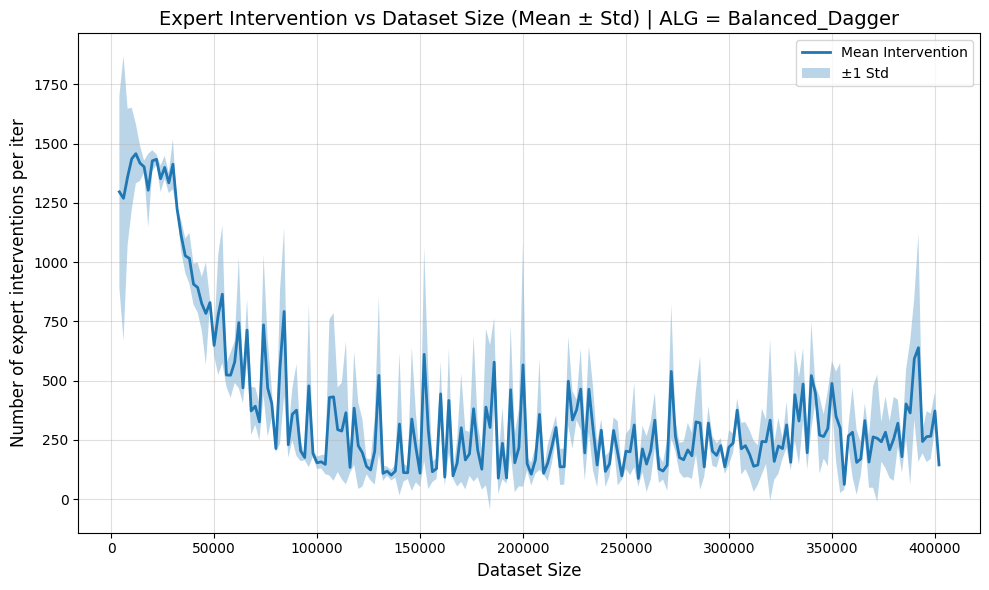

In [ ]:
# expert intervention plot 


import json
import os
import numpy as np
import matplotlib.pyplot as plt


def plot_nswitch_from_checkpoints(checkpoint_roots):

    all_nswitches = []
    all_dataset_sizes = []

    # --------------------------------
    # Load all results first
    # --------------------------------
    for root in checkpoint_roots:
        result_path = os.path.join(root, "results.json")

        if not os.path.exists(result_path):
            raise FileNotFoundError(f"results.json not found: {result_path}")

        with open(result_path, "r") as f:
            results = json.load(f)

        dataset_sizes = np.array(results["dataset_sizes"])
        nswitches = np.array(results["nswitches"])

        all_dataset_sizes.append(dataset_sizes)
        all_nswitches.append(nswitches)

    # --------------------------------
    # Find minimum length
    # --------------------------------
    min_len = min(len(x) for x in all_nswitches)
    print(f"[INFO] Min common length = {min_len}")

    # --------------------------------
    # Crop to minimum length
    # --------------------------------
    all_nswitches = [x[:min_len] for x in all_nswitches]
    all_dataset_sizes = [x[:min_len] for x in all_dataset_sizes]

    # reference x-axis (첫 번째 실험 기준)
    dataset_sizes_ref = all_dataset_sizes[0]

    # stack: (N, min_len)
    all_nswitches = np.stack(all_nswitches, axis=0)

    # --------------------------------
    # Mean / Std
    # --------------------------------
    mean_nswitch = np.mean(all_nswitches, axis=0)
    std_nswitch  = np.std(all_nswitches, axis=0)

    # --------------------------------
    # Plot
    # --------------------------------
    plt.figure(figsize=(10, 6))

    plt.plot(dataset_sizes_ref, mean_nswitch,
             linewidth=2,
             label="Mean Intervention")

    plt.fill_between(
        dataset_sizes_ref,
        mean_nswitch - std_nswitch,
        mean_nswitch + std_nswitch,
        alpha=0.3,
        label="±1 Std"
    )

    plt.xlabel("Dataset Size", fontsize=12)
    plt.ylabel("Number of expert interventions per iter", fontsize=12)
    plt.title("Expert Intervention vs Dataset Size (Mean ± Std) | ALG = Balanced_Dagger", fontsize=14)


    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


checkpoint_dirs = [
    "/AILAB-summer-school-2025/checkpoints/total/[Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.7_minDemo70_H0_FTrue_seed2",
    "/AILAB-summer-school-2025/checkpoints/total/[Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.7_minDemo70_H0_FTrue_seed13",
    "/AILAB-summer-school-2025/checkpoints/total/[Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.7_minDemo70_H0_FTrue_seed42",
]

plot_nswitch_from_checkpoints(checkpoint_dirs)


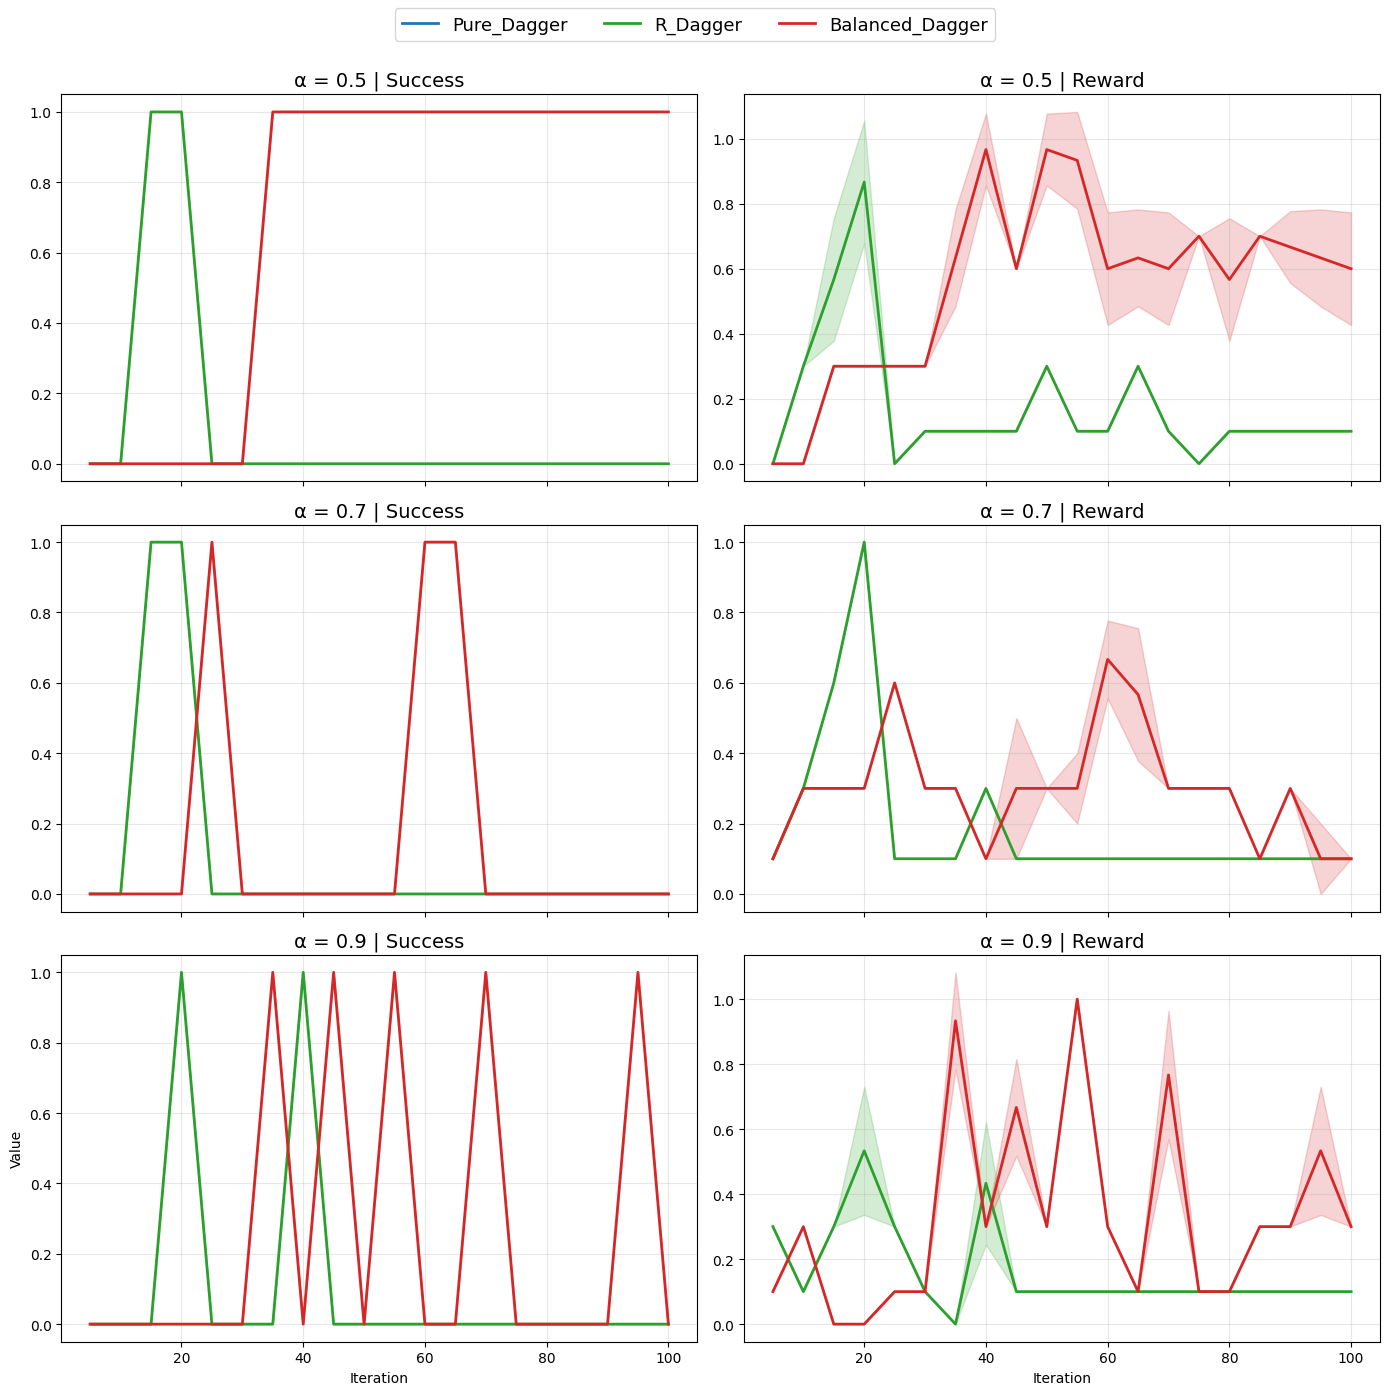

[SAVED] dagger_eval_plot.png


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

def plot_success_reward(json_path, seed, save_path="eval_all_plot.png"):

    # -------------------------
    # 1. JSON 로드
    # -------------------------
    with open(json_path, "r") as f:
        data = json.load(f)

    algorithms = ["Pure_Dagger", "R_Dagger", "Balanced_Dagger"]
    colors = {
        "Pure_Dagger": "tab:blue",
        "R_Dagger": "tab:green",
        "Balanced_Dagger": "tab:red",
    }

    # -------------------------
    # 2. α 리스트 자동 수집
    # -------------------------
    alpha_list = sorted({float(alpha_key)
                         for algo in data.values()
                         for alpha_key in algo.keys()})

    fig, axes = plt.subplots(
        nrows=len(alpha_list),
        ncols=2,
        figsize=(14, 14),
        sharex=True
    )

    alpha_to_row = {alpha: idx for idx, alpha in enumerate(alpha_list)}

    # -------------------------
    # 3. algo → alpha loop
    # -------------------------
    for algo in algorithms:

        if algo not in data:
            continue

        # ================================================================
        # Case 1: Pure_Dagger → 모든 α-row에 그리는 특별 처리
        # ================================================================
        if algo == "Pure_Dagger":
            one_alpha_key = list(data[algo].keys())[0]
            alpha_entry = data[algo][one_alpha_key]

            if str(seed) not in alpha_entry["seeds"]:
                continue

            iter_results = alpha_entry["seeds"][str(seed)]["iter_results"]
            iters = sorted([int(k) for k in iter_results.keys()])

            # iter별 계산
            success_mean_list = []
            success_std_list = []
            reward_mean_list = []
            reward_std_list = []

            for it in iters:
                res = iter_results[str(it)]
                succ_tail = res["success_list"][3:]
                rew_tail = res["reward_list"][3:]
                
                success_mean_list.append(np.mean(succ_tail))
                success_std_list.append(np.std(succ_tail))
                reward_mean_list.append(np.mean(rew_tail))
                reward_std_list.append(np.std(rew_tail))

            # numpy 변환
            success_mean_list = np.array(success_mean_list)
            success_std_list = np.array(success_std_list)
            reward_mean_list = np.array(reward_mean_list)
            reward_std_list = np.array(reward_std_list)

            # Pure_Dagger 는 모든 α-row에 반복해서 그림
            for alpha in alpha_list:
                row_idx = alpha_to_row[alpha]
                ax_success = axes[row_idx][0]
                ax_reward  = axes[row_idx][1]

                ax_success.plot(
                    iters, success_mean_list,
                    label=algo, color=colors[algo], linewidth=2
                )
                ax_success.fill_between(
                    iters,
                    success_mean_list - success_std_list,
                    success_mean_list + success_std_list,
                    alpha=0.2,
                    color=colors[algo]
                )

                ax_reward.plot(
                    iters, reward_mean_list,
                    label=algo, color=colors[algo], linewidth=2
                )
                ax_reward.fill_between(
                    iters,
                    reward_mean_list - reward_std_list,
                    reward_mean_list + reward_std_list,
                    alpha=0.2,
                    color=colors[algo]
                )

            continue  # Balanced/R_Dagger 처리를 위해 다음으로 넘어감

        # ================================================================
        # Case 2: R_Dagger, Balanced_Dagger (기존 로직 유지)
        # ================================================================
        for alpha_key, alpha_entry in data[algo].items():

            alpha = float(alpha_key)
            row_idx = alpha_to_row.get(alpha, None)
            if row_idx is None:
                continue

            if str(seed) not in alpha_entry["seeds"]:
                continue

            iter_results = alpha_entry["seeds"][str(seed)]["iter_results"]
            iters = sorted([int(k) for k in iter_results.keys()])

            success_mean_list = []
            success_std_list = []
            reward_mean_list = []
            reward_std_list = []

            for it in iters:
                res = iter_results[str(it)]
                succ_tail = res["success_list"][3:] 
                rew_tail = res["reward_list"][3:]   

                success_mean_list.append(np.mean(succ_tail))
                success_std_list.append(np.std(succ_tail))
                reward_mean_list.append(np.mean(rew_tail))
                reward_std_list.append(np.std(rew_tail))

            success_mean_list = np.array(success_mean_list)
            success_std_list = np.array(success_std_list)
            reward_mean_list = np.array(reward_mean_list)
            reward_std_list = np.array(reward_std_list)

            ax_success = axes[row_idx][0]
            ax_reward = axes[row_idx][1]

            ax_success.plot(iters, success_mean_list,
                            label=algo, color=colors[algo], linewidth=2)
            ax_success.fill_between(
                iters,
                success_mean_list - success_std_list,
                success_mean_list + success_std_list,
                alpha=0.2,
                color=colors[algo]
            )

            ax_reward.plot(iters, reward_mean_list,
                           label=algo, color=colors[algo], linewidth=2)
            ax_reward.fill_between(
                iters,
                reward_mean_list - reward_std_list,
                reward_mean_list + reward_std_list,
                alpha=0.2,
                color=colors[algo]
            )

    # -------------------------
    # row title / grid
    # -------------------------
    for alpha in alpha_list:
        row_idx = alpha_to_row[alpha]
        axes[row_idx][0].set_title(f"α = {alpha} | Success", fontsize=14)
        axes[row_idx][1].set_title(f"α = {alpha} | Reward", fontsize=14)
        axes[row_idx][0].grid(True, alpha=0.3)
        axes[row_idx][1].grid(True, alpha=0.3)

    # 마지막 row xlabel
    last_row = len(alpha_list) - 1
    axes[last_row][0].set_xlabel("Iteration")
    axes[last_row][1].set_xlabel("Iteration")
    axes[last_row][0].set_ylabel("Value")

    # -------------------------
    # 전체 legend
    # -------------------------
    handles = []
    labels = []

    for ax in axes.flatten():
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

    by_label = dict(zip(labels, handles))  # label 중복 제거
    fig.legend(by_label.values(), by_label.keys(), loc="upper center", ncol=3, fontsize=13)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(save_path, dpi=200)
    plt.show()
    plt.close()
    print(f"[SAVED] {save_path}")

plot_success_reward(
    json_path="/AILAB-summer-school-2025/eval_all_iters.json",
    seed=2,
    save_path="dagger_eval_plot.png"
)

In [4]:
import os 
for f in os.listdir("/AILAB-summer-school-2025/checkpoints/total"):
    print("RAW:", repr(f))

    if "Decorate this" in f:  # placeholder
        pass

    if "[Pure_Dagger]" in f:
        print("FOUND PURE:", f)
    else:
        print("NOT PURE:", f)

    if "alpha_0.5" in f:
        print("HAS ALPHA:", f)
    else:
        print("NO ALPHA:", f)

RAW: '[Pure_Dagger]rnd_iter200_balance_False_epoch_10_alpha_0.5_minDemo70_H0_FTrue_seed13'
FOUND PURE: [Pure_Dagger]rnd_iter200_balance_False_epoch_10_alpha_0.5_minDemo70_H0_FTrue_seed13
HAS ALPHA: [Pure_Dagger]rnd_iter200_balance_False_epoch_10_alpha_0.5_minDemo70_H0_FTrue_seed13
RAW: '[Pure_Dagger]rnd_iter200_balance_False_epoch_10_alpha_0.5_minDemo70_H0_FTrue_seed2'
FOUND PURE: [Pure_Dagger]rnd_iter200_balance_False_epoch_10_alpha_0.5_minDemo70_H0_FTrue_seed2
HAS ALPHA: [Pure_Dagger]rnd_iter200_balance_False_epoch_10_alpha_0.5_minDemo70_H0_FTrue_seed2
RAW: '[Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.9_minDemo70_H0_FTrue_seed2'
NOT PURE: [Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.9_minDemo70_H0_FTrue_seed2
NO ALPHA: [Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.9_minDemo70_H0_FTrue_seed2
RAW: '[Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.5_minDemo70_H0_FTrue_seed42'
NOT PURE: [Balanced_Dagger]rnd_iter200_balance_True_epoch_10